# FairRoute — Hypothesis Matrix Analysis (Custom Modified LLM Serving Sim)

This notebook analyzes **all outputs produced by `run_fairroute_hypothesis_matrix.sh`**
running against the custom-modified LLM Serving Sim (extra per-request columns for
routing score, fairness debt/urgency, locality, prediction, and cache-tier hits).

The matrix script sweeps **30 routing policies** across **6 workload scenarios**
(`balanced_control`, `fairness_conflict`, `locality_conflict`, `prediction_burst`,
`full_adversarial`, `real_workload_1000`), producing one per-request CSV and one
per-replica timeseries CSV per (scenario, policy) pair — 168 runs in total when complete.

### Policy taxonomy analyzed
| Category | Policies |
|---|---|
| Naive baselines | `RR`, `LOAD`, `RAND` |
| Single-signal ablations | `FAIRNESS`, `LOCALITY`, `PREDICTION` |
| Pairwise ablations | `F_L`, `L_P`, `F_P` |
| Naive linear triple | `F_L_P` |
| Prior-art baselines | `PREBLE`, `LBGR`, `DUALMAP`, `CACHE_ROUTE`, `VTC`, `EQUINOX`, `QUARTZ`, `ISJL`, `NEXUSSCHED`, `BALANCEROUTE`, `PILLM`, `ONLINE_LP` |
| **Combination-form hypotheses** (the sharpest novel axis) | `H0`, `H1`, `H2`, `H3`, `H4`, `H5` |
| **FairRoute (final / v2)** | `FAIRROUTE`, `FAIRROUTE_V2` |

### Notebook outline
0. Setup & configuration
1. Load the full hypothesis matrix (168 request-level + 168 timeseries CSVs) & integrity check
2. Per-(scenario, policy) summary metrics — fairness, locality, prediction, latency, throughput, SLO, energy
3. Cross-scenario heatmaps for the core axes
4. Category-level comparison (naive vs. single-signal vs. prior-art vs. hypothesis forms)
5. **Combination-form deep dive**: H0–H5 vs. FAIRROUTE / FAIRROUTE_V2 (linear / multiplicative / gated / learned)
6. Predictive validity: does the `prediction` signal actually track future load?
7. Overall leaderboard — rank aggregation across all scenarios
8. Single-scenario deep dive (parameterizable causal-chain view)
9. Export results


## 0. Setup & configuration

In [1]:

import os
import re
import glob
import ast
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# ---------------------------------------------------------------------------
# DATA_DIR: point this at the folder produced by run_fairroute_hypothesis_matrix.sh
# (i.e. the directory that directly contains "<scenario>_policy_<POLICY>.csv" files,
# named "fairroute_hypothesis" by default in the script's OUTPUT_DIR variable).
# We try a few common locations and fall back to the first one that exists.
# ---------------------------------------------------------------------------
_CANDIDATES = [
    os.environ.get("FAIRROUTE_DATA_DIR", ""),
    "./fairroute_hypothesis",
    "./outputs/fairroute_hypothesis",
    "../outputs/fairroute_hypothesis",
    "/mnt/user-data/uploads/fairroute_hypothesis",
    "/mnt/user-data/uploads",
]
DATA_DIR = next((p for p in _CANDIDATES if p and os.path.isdir(p)
                  and glob.glob(os.path.join(p, "*_policy_*.csv"))), None)
if DATA_DIR is None:
    DATA_DIR = "./fairroute_hypothesis"  # edit this manually if auto-detect fails
print(f"Using DATA_DIR = {DATA_DIR!r}")

SLO_TTFT_MS = 100.0      # time-to-first-token SLO
SLO_E2E_MS = 15000.0     # end-to-end latency SLO

# ---------------------------------------------------------------------------
# Policy taxonomy
# ---------------------------------------------------------------------------
POLICY_CATEGORY = {
    "RR": "Naive", "LOAD": "Naive", "RAND": "Naive",
    "FAIRNESS": "Single-Signal", "LOCALITY": "Single-Signal", "PREDICTION": "Single-Signal",
    "F_L": "Pairwise", "L_P": "Pairwise", "F_P": "Pairwise",
    "F_L_P": "Naive Linear Triple",
    "PREBLE": "Prior Art", "LBGR": "Prior Art", "DUALMAP": "Prior Art",
    "CACHE_ROUTE": "Prior Art", "VTC": "Prior Art", "EQUINOX": "Prior Art",
    "QUARTZ": "Prior Art", "ISJL": "Prior Art", "NEXUSSCHED": "Prior Art",
    "BALANCEROUTE": "Prior Art", "PILLM": "Prior Art", "ONLINE_LP": "Prior Art",
    "H0": "Combination-Form Hypothesis", "H1": "Combination-Form Hypothesis",
    "H2": "Combination-Form Hypothesis", "H3": "Combination-Form Hypothesis",
    "H4": "Combination-Form Hypothesis", "H5": "Combination-Form Hypothesis",
    "FAIRROUTE": "FairRoute (Final)", "FAIRROUTE_V2": "FairRoute (v2 / H5)",
}

POLICY_ORDER = [
    "RR", "LOAD", "RAND",
    "FAIRNESS", "LOCALITY", "PREDICTION",
    "F_L", "L_P", "F_P", "F_L_P",
    "PREBLE", "LBGR", "DUALMAP", "CACHE_ROUTE", "VTC", "EQUINOX", "QUARTZ", "ISJL",
    "NEXUSSCHED", "BALANCEROUTE", "PILLM", "ONLINE_LP",
    "H0", "H1", "H2", "H3", "H4", "H5", "FAIRROUTE", "FAIRROUTE_V2",
]

CATEGORY_COLOR = {
    "Naive": "#9e9e9e",
    "Single-Signal": "#64b5f6",
    "Pairwise": "#4fc3f7",
    "Naive Linear Triple": "#26a69a",
    "Prior Art": "#ba68c8",
    "Combination-Form Hypothesis": "#ffb74d",
    "FairRoute (Final)": "#e53935",
    "FairRoute (v2 / H5)": "#d32f2f",
}
PALETTE = {p: CATEGORY_COLOR[c] for p, c in POLICY_CATEGORY.items()}

FORM_POLICIES = ["H0", "H1", "H2", "H3", "H4", "H5", "FAIRROUTE", "FAIRROUTE_V2"]
SCENARIO_ORDER = [
    "balanced_control", "fairness_conflict", "locality_conflict",
    "prediction_burst", "full_adversarial", "real_workload_1000",
]

def jains_index(values):
    """Jain's Fairness Index over a set of per-client service totals."""
    values = np.asarray(list(values), dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0 or values.sum() <= 0:
        return 1.0
    return (values.sum() ** 2) / (len(values) * np.square(values).sum())

def itl_jitter_cv(itl_str):
    """Coefficient of variation of inter-token latency, parsed from the raw
    cumulative-timestamp ITL list stored per request."""
    try:
        vals = ast.literal_eval(itl_str)
        if not isinstance(vals, list) or len(vals) < 3:
            return np.nan
        diffs = np.diff(np.asarray(vals, dtype=float))
        diffs = diffs[diffs >= 0]
        if len(diffs) == 0 or diffs.mean() == 0:
            return np.nan
        return diffs.std() / diffs.mean()
    except Exception:
        return np.nan

def savefig_note(title):
    plt.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()

def ordered(items, order):
    present = [p for p in order if p in set(items)]
    rest = [p for p in items if p not in order]
    return present + rest


Using DATA_DIR = '../outputs/fairroute_hypothesis'


## 1. Load the full hypothesis matrix & integrity check

In [2]:

run_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*_policy_*.csv")))
run_paths = [p for p in run_paths if not p.endswith("_timeseries.csv")]
print(f"Found {len(run_paths)} per-request result files in {DATA_DIR}")

_FILENAME_RE = re.compile(r"^(?P<scenario>.+)_policy_(?P<policy>[A-Z0-9_]+)\.csv$")

frames = []
for path in run_paths:
    fname = os.path.basename(path)
    m = _FILENAME_RE.match(fname)
    if not m:
        continue
    frame = pd.read_csv(path)
    frame["scenario"] = m.group("scenario")
    frame["policy_name"] = m.group("policy").upper()
    frames.append(frame)

assert frames, f"No matrix outputs found under {DATA_DIR} — check DATA_DIR."
requests_df = pd.concat(frames, ignore_index=True)

# --- unit conversions (raw fields are nanoseconds) ---
for src, dst in [("latency", "latency_ms"), ("queuing_delay", "queuing_delay_ms"),
                  ("TTFT", "TTFT_ms"), ("TPOT", "TPOT_ms")]:
    requests_df[dst] = requests_df[src] / 1e6

requests_df["prefix_hit_ratio"] = (
    requests_df["prefix_cache_hit"] / requests_df["input"].replace(0, np.nan)
).fillna(0.0).clip(0, 1)

requests_df["cache_hit_tokens"] = (
    requests_df[["prefix_cache_hit", "npu_cache_hit", "storage_cache_hit"]].max(axis=1)
)

requests_df["slo_met"] = (
    (requests_df["TTFT_ms"] <= SLO_TTFT_MS) & (requests_df["latency_ms"] <= SLO_E2E_MS)
)
requests_df["queue_delay_fraction"] = (
    requests_df["queuing_delay_ms"] / requests_df["latency_ms"].replace(0, np.nan)
).fillna(0.0)

requests_df["category"] = requests_df["policy_name"].map(POLICY_CATEGORY).fillna("Other")
requests_df["scenario"] = pd.Categorical(requests_df["scenario"], categories=SCENARIO_ORDER, ordered=True)
requests_df["policy_name"] = pd.Categorical(requests_df["policy_name"], categories=POLICY_ORDER, ordered=True)

print(f"Loaded {len(requests_df):,} requests across "
      f"{requests_df['scenario'].nunique()} scenarios x {requests_df['policy_name'].nunique()} policies")

coverage = requests_df.groupby(["scenario", "policy_name"], observed=True).size().unstack(fill_value=0)
missing = coverage[coverage.columns[(coverage == 0).any()]] if (coverage == 0).values.any() else None
print("\n=== Run coverage (rows per scenario x policy) ===")
display(coverage)
if (coverage == 0).values.any():
    print("\n WARNING: missing (scenario, policy) combinations detected above (cells = 0).")
else:
    print("\nFull matrix present: no missing (scenario, policy) combinations.")


Found 180 per-request result files in ../outputs/fairroute_hypothesis
Loaded 60,000 requests across 6 scenarios x 30 policies

=== Run coverage (rows per scenario x policy) ===


policy_name,RR,LOAD,RAND,FAIRNESS,LOCALITY,PREDICTION,F_L,L_P,F_P,F_L_P,PREBLE,LBGR,DUALMAP,CACHE_ROUTE,VTC,EQUINOX,QUARTZ,ISJL,NEXUSSCHED,BALANCEROUTE,PILLM,ONLINE_LP,H0,H1,H2,H3,H4,H5,FAIRROUTE,FAIRROUTE_V2
scenario,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
balanced_control,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
fairness_conflict,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
locality_conflict,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
prediction_burst,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
full_adversarial,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
real_workload_1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000



Full matrix present: no missing (scenario, policy) combinations.


In [3]:

# Matrix run-health, if the script's own status/log files are present alongside the CSVs
status_path = os.path.join(DATA_DIR, "matrix_status.txt")
if os.path.isfile(status_path):
    with open(status_path, "r", errors="replace") as fh:
        print("=== matrix_status.txt ===")
        print(fh.read().strip())
else:
    print("No matrix_status.txt found (this is informational only).")


=== matrix_status.txt ===
2026-09-15T07:08:55+00:00 status=COMPLETE cache_mode=xpu total=180 completed=180 skipped=0 active=0 failed=0 remaining=0 current=


In [4]:

# --- Timeseries (per-replica system-pressure) CSVs ---
ts_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*_policy_*_timeseries.csv")))
ts_frames = []
for path in ts_paths:
    fname = os.path.basename(path)
    m = re.match(r"^(?P<scenario>.+)_policy_(?P<policy>[A-Z0-9_]+)_timeseries\.csv$", fname)
    if not m:
        continue
    t = pd.read_csv(path)
    t["scenario"] = m.group("scenario")
    t["policy_name"] = m.group("policy").upper()
    ts_frames.append(t)

if ts_frames:
    ts_df = pd.concat(ts_frames, ignore_index=True)
    ts_df["scenario"] = pd.Categorical(ts_df["scenario"], categories=SCENARIO_ORDER, ordered=True)
    ts_df["policy_name"] = pd.Categorical(ts_df["policy_name"], categories=POLICY_ORDER, ordered=True)
    print(f"Loaded {len(ts_df):,} timeseries samples from {len(ts_paths)} files")
else:
    ts_df = pd.DataFrame()
    print("No timeseries CSVs found.")


Loaded 29,308 timeseries samples from 180 files


## 2. Per-(scenario, policy) summary metrics

One row per (scenario, policy) combination covering routing behaviour, fairness,
locality, prediction, latency, throughput, preemption, SLO/goodput, and an energy
proxy — the full metrics framework from the Experimental Roadmap, computed across
the entire matrix at once.

In [5]:

GROUP = ["scenario", "policy_name"]

# --- fairness: Jain's index over per-client total output tokens ---
client_service = (
    requests_df.groupby(GROUP + ["client id"], observed=True)["output"].sum().reset_index()
)
jain_tbl = (
    client_service.groupby(GROUP, observed=True)["output"]
    .apply(jains_index).reset_index(name="jains_index")
)

# --- replica load balance: coefficient of variation of requests/replica ---
replica_load = (
    requests_df.groupby(GROUP + ["instance id"], observed=True).size().reset_index(name="n")
)
load_cv_tbl = (
    replica_load.groupby(GROUP, observed=True)["n"]
    .apply(lambda x: x.std(ddof=0) / x.mean() if x.mean() else 0.0)
    .reset_index(name="replica_load_cv")
)

# --- decode jitter from ITL (coefficient of variation of inter-token latency) ---
print("Parsing ITL token-timing lists for decode-jitter (this takes ~30-60s for the full matrix)...")
requests_df["itl_cv"] = requests_df["ITL"].apply(itl_jitter_cv)

# --- correlation between predicted benefit and actual queueing delay realized ---
def _pred_corr(g):
    if g["prediction"].nunique() < 2:
        return np.nan
    return g["prediction"].corr(g["queuing_delay_ms"])
pred_corr_tbl = (
    requests_df.groupby(GROUP, observed=True)
    .apply(_pred_corr).reset_index(name="prediction_vs_actual_queue_corr")
)

# --- main aggregate summary ---
summary = requests_df.groupby(GROUP, observed=True).agg(
    n_requests=("request id", "count"),
    n_clients=("client id", "nunique"),
    n_replicas=("instance id", "nunique"),
    mean_fairness_debt=("fairness debt", "mean"),
    p95_fairness_debt=("fairness debt", lambda x: np.percentile(x, 95)),
    max_fairness_debt=("fairness debt", "max"),
    mean_fairness_urgency=("fairness urgency", "mean"),
    mean_prefix_hit_ratio=("prefix_hit_ratio", "mean"),
    total_recompute_tokens=("recompute_tokens", "sum"),
    total_cache_hit_tokens=("cache_hit_tokens", "sum"),
    mean_routing_score=("routing score", "mean"),
    mean_score_margin=("routing score margin", "mean"),
    ttft_p50_ms=("TTFT_ms", lambda x: x.quantile(0.50)),
    ttft_p99_ms=("TTFT_ms", lambda x: x.quantile(0.99)),
    tpot_p50_ms=("TPOT_ms", lambda x: x.quantile(0.50)),
    tpot_p99_ms=("TPOT_ms", lambda x: x.quantile(0.99)),
    e2e_p50_ms=("latency_ms", lambda x: x.quantile(0.50)),
    e2e_p99_ms=("latency_ms", lambda x: x.quantile(0.99)),
    queue_p50_ms=("queuing_delay_ms", lambda x: x.quantile(0.50)),
    queue_p99_ms=("queuing_delay_ms", lambda x: x.quantile(0.99)),
    mean_queue_delay_fraction=("queue_delay_fraction", "mean"),
    mean_itl_jitter_cv=("itl_cv", "mean"),
    total_preemptions=("num_preemptions", "sum"),
    slo_attainment_pct=("slo_met", lambda x: 100.0 * x.mean()),
    total_output_tokens=("output", "sum"),
    end_time_s=("end_time", lambda x: x.max() / 1e9),
).reset_index()

summary["req_throughput_sps"] = summary["n_requests"] / summary["end_time_s"].replace(0, np.nan)
summary["token_throughput_tps"] = summary["total_output_tokens"] / summary["end_time_s"].replace(0, np.nan)
summary["goodput_sps"] = (summary["slo_attainment_pct"] / 100.0) * summary["req_throughput_sps"]
summary["energy_proxy_kj"] = (summary["end_time_s"] * 250.0) / 1000.0  # 250W NPU proxy, wall-clock basis

summary = (
    summary.merge(jain_tbl, on=GROUP)
    .merge(load_cv_tbl, on=GROUP)
    .merge(pred_corr_tbl, on=GROUP)
)
summary["category"] = summary["policy_name"].map(POLICY_CATEGORY)

# --- fold in timeseries system-pressure signals, if available ---
if not ts_df.empty:
    ts_summary = ts_df.groupby(GROUP, observed=True).agg(
        mean_kv_util_pct=("kv_util_pct", "mean"),
        peak_kv_util_pct=("kv_util_pct", "max"),
        mean_waiting_reqs=("waiting_reqs", "mean"),
        mean_npu_util_pct=("npu_util_pct", "mean"),
    ).reset_index()
    summary = summary.merge(ts_summary, on=GROUP, how="left")

summary = summary.round(4)
print(f"Summary table: {summary.shape[0]} (scenario, policy) rows x {summary.shape[1]} metrics")
display(summary.head(10))


Parsing ITL token-timing lists for decode-jitter (this takes ~30-60s for the full matrix)...
Summary table: 180 (scenario, policy) rows x 40 metrics


,scenario,policy_name,n_requests,n_clients,n_replicas,mean_fairness_debt,p95_fairness_debt,max_fairness_debt,mean_fairness_urgency,mean_prefix_hit_ratio,total_recompute_tokens,total_cache_hit_tokens,mean_routing_score,mean_score_margin,ttft_p50_ms,ttft_p99_ms,tpot_p50_ms,tpot_p99_ms,e2e_p50_ms,e2e_p99_ms,queue_p50_ms,queue_p99_ms,mean_queue_delay_fraction,mean_itl_jitter_cv,total_preemptions,slo_attainment_pct,total_output_tokens,end_time_s,req_throughput_sps,token_throughput_tps,goodput_sps,energy_proxy_kj,jains_index,replica_load_cv,prediction_vs_actual_queue_corr,category,mean_kv_util_pct,peak_kv_util_pct,mean_waiting_reqs,mean_npu_util_pct
0,balanced_control,RR,200,10,4,0.0000,0.0000,0.0,0.0000,0.0,101668,0,0.0000,0.0000,30.0081,44.1314,11.6880,11.9367,1509.5373,2248.5736,6.0020,11.0923,0.0040,6.4999,0,100.0,25487,21.4986,9.3029,1185.5209,9.3029,5.3746,0.9948,0.0000,NaN,Naive,0.5111,1.078,0.1786,22.1918
1,balanced_control,LOAD,200,10,4,0.0000,0.0000,0.0,0.0000,0.0,101668,0,0.0000,0.0000,29.3513,44.7865,11.8582,12.3832,1526.6061,2266.4220,5.0284,11.1197,0.0037,5.7903,0,100.0,25487,21.5032,9.3010,1185.2675,9.3010,5.3758,0.9948,0.5050,NaN,Naive,0.4322,0.812,0.1667,21.9447
2,balanced_control,RAND,200,10,4,0.0000,0.0000,0.0,0.0000,0.0,101668,0,0.0000,0.0000,30.5468,43.9846,11.7691,12.2964,1518.5712,2252.5060,5.9529,11.1611,0.0041,6.4006,0,100.0,25487,21.5053,9.3000,1185.1502,9.3000,5.3763,0.9948,0.1304,NaN,Naive,0.5171,1.468,0.1429,22.1977
3,balanced_control,FAIRNESS,200,10,4,0.0858,0.3883,1.0,0.1087,0.0,101668,0,0.1019,0.0015,30.2553,43.7037,11.7711,12.2666,1499.4719,2245.3273,5.5656,10.9288,0.0040,6.3818,0,100.0,25487,21.5054,9.3000,1185.1441,9.3000,5.3764,0.9948,0.3308,0.0214,Single-Signal,0.4463,0.911,0.1786,22.0137
4,balanced_control,LOCALITY,200,10,4,0.0866,0.3824,1.0,0.1098,0.0,101668,0,0.0000,0.0000,30.4582,43.5707,11.7383,12.2509,1510.9301,2299.7889,5.9766,11.1698,0.0041,6.4028,0,100.0,25487,21.4924,9.3056,1185.8598,9.3056,5.3731,0.9948,0.1281,-0.0823,Single-Signal,0.4994,1.447,0.1905,22.1645
5,balanced_control,PREDICTION,200,10,4,0.0852,0.3842,1.0,0.1075,0.0,101668,0,0.9348,0.0133,30.5398,44.6237,11.8626,12.2241,1530.0204,2287.2136,5.8498,11.1805,0.0041,5.8646,0,100.0,25487,21.4931,9.3053,1185.8207,9.3053,5.3733,0.9948,0.4810,-0.2282,Single-Signal,0.4316,0.768,0.2262,21.9312
6,balanced_control,F_L,200,10,4,0.0858,0.3883,1.0,0.1087,0.0,101668,0,0.1019,0.0015,30.2553,43.7037,11.7711,12.2666,1499.4719,2245.3273,5.5656,10.9288,0.0040,6.3818,0,100.0,25487,21.5054,9.3000,1185.1441,9.3000,5.3764,0.9948,0.3308,0.0214,Pairwise,0.4463,0.911,0.1786,22.0137
7,balanced_control,L_P,200,10,4,0.0852,0.3842,1.0,0.1075,0.0,101668,0,0.9348,0.0133,30.5398,44.6237,11.8626,12.2241,1530.0204,2287.2136,5.8498,11.1805,0.0041,5.8646,0,100.0,25487,21.4931,9.3053,1185.8207,9.3053,5.3733,0.9948,0.4810,-0.2282,Pairwise,0.4316,0.768,0.2262,21.9312
8,balanced_control,F_P,200,10,4,0.0852,0.3842,1.0,0.1075,0.0,101668,0,1.0348,0.0148,30.5398,44.6237,11.8626,12.2241,1530.0204,2287.2136,5.8498,11.1805,0.0041,5.8646,0,100.0,25487,21.4931,9.3053,1185.8207,9.3053,5.3733,0.9948,0.4810,-0.2282,Pairwise,0.4316,0.768,0.2262,21.9312
9,balanced_control,F_L_P,200,10,4,0.0852,0.3842,1.0,0.1075,0.0,101668,0,1.0348,0.0148,30.5398,44.6237,11.8626,12.2241,1530.0204,2287.2136,5.8498,11.1805,0.0041,5.8646,0,100.0,25487,21.4931,9.3053,1185.8207,9.3053,5.3733,0.9948,0.4810,-0.2282,Naive Linear Triple,0.4316,0.768,0.2262,21.9312


In [6]:

os.makedirs("/home/sriram/sem7/p1/mnt/user-data/outputs", exist_ok=True)
summary.to_csv("/home/sriram/sem7/p1/mnt/user-data/outputs/fairroute_hypothesis_summary.csv", index=False)
print("Saved full per-(scenario,policy) summary to fairroute_hypothesis_summary.csv")


Saved full per-(scenario,policy) summary to fairroute_hypothesis_summary.csv


## 3. Cross-scenario heatmaps for the core axes

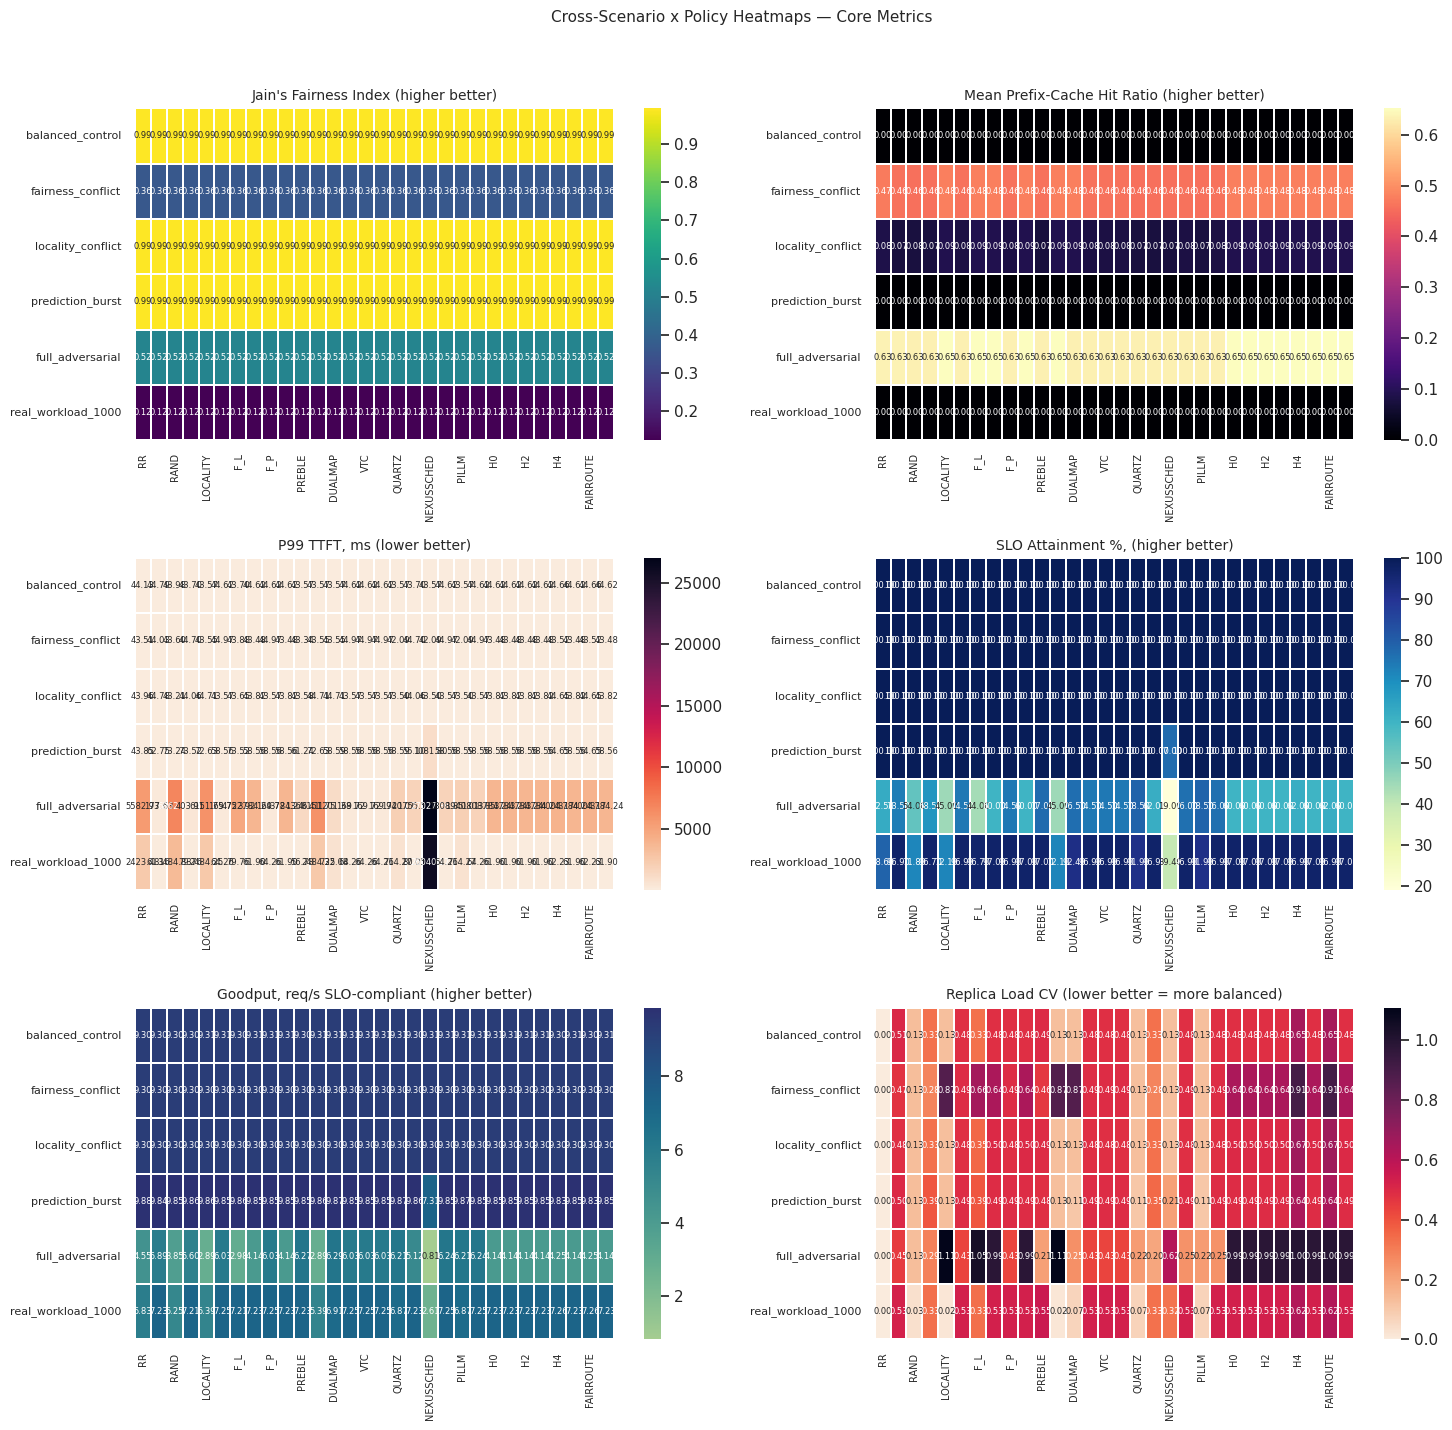

In [7]:

heatmap_metrics = [
    ("jains_index", "Jain's Fairness Index (higher better)", "viridis"),
    ("mean_prefix_hit_ratio", "Mean Prefix-Cache Hit Ratio (higher better)", "magma"),
    ("ttft_p99_ms", "P99 TTFT, ms (lower better)", "rocket_r"),
    ("slo_attainment_pct", "SLO Attainment %, (higher better)", "YlGnBu"),
    ("goodput_sps", "Goodput, req/s SLO-compliant (higher better)", "crest"),
    ("replica_load_cv", "Replica Load CV (lower better = more balanced)", "rocket_r"),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for axis, (metric, title, cmap) in zip(axes.flat, heatmap_metrics):
    pivot = summary.pivot(index="scenario", columns="policy_name", values=metric)
    pivot = pivot.reindex(columns=[p for p in POLICY_ORDER if p in pivot.columns])
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=axis,
                cbar=True, annot_kws={"size": 6}, linewidths=0.3)
    axis.set_title(title, fontsize=10)
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.tick_params(axis="x", rotation=90, labelsize=7)
    axis.tick_params(axis="y", rotation=0, labelsize=8)
savefig_note("Cross-Scenario x Policy Heatmaps — Core Metrics")
plt.show()


## 4. Category-level comparison

Groups the 30 policies into the taxonomy above and compares them across scenarios,
to see whether *any* signal combination beats the naive baselines, and whether
prior-art single/dual-concern routers plateau where FairRoute's joint score does not.

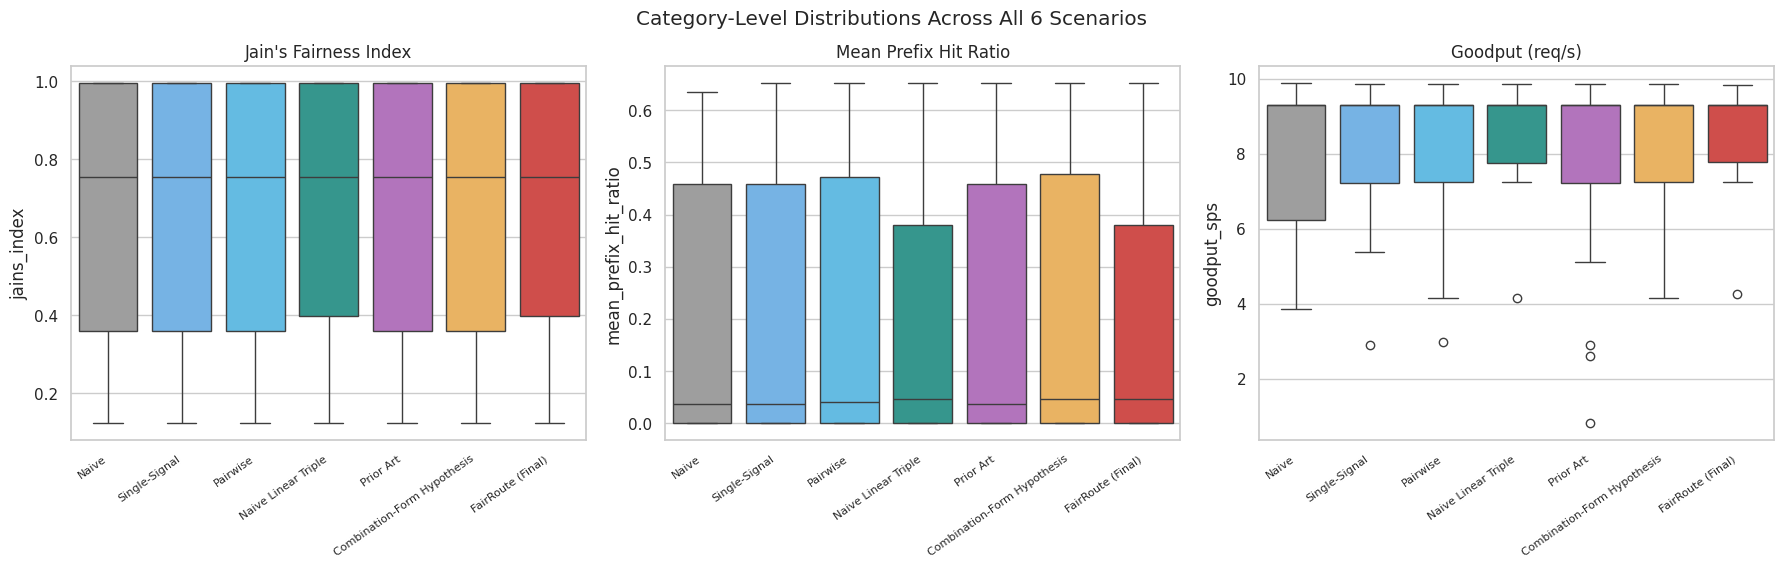

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
metric_specs = [
    ("jains_index", "Jain's Fairness Index"),
    ("mean_prefix_hit_ratio", "Mean Prefix Hit Ratio"),
    ("goodput_sps", "Goodput (req/s)"),
]
cat_order = ["Naive", "Single-Signal", "Pairwise", "Naive Linear Triple",
             "Prior Art", "Combination-Form Hypothesis", "FairRoute (Final)"]
for axis, (metric, title) in zip(axes, metric_specs):
    sns.boxplot(data=summary, x="category", y=metric, order=cat_order,
                palette=CATEGORY_COLOR, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35, labelsize=8)
    for label in axis.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.suptitle("Category-Level Distributions Across All 6 Scenarios", y=1.03)
plt.show()


## 5. Combination-form deep dive — H0–H5 vs. FAIRROUTE / FAIRROUTE_V2

This is the sharpest novel experimental axis: for a *fixed* set of fairness/locality/
prediction signals, does the way they are combined (linear `H0`, multiplicative `H1`,
gated/lexicographic `H2`/`H3`, learned `H4`, deficit-driven `H5`/`FAIRROUTE_V2`) change outcomes, and does FairRoute's
selected form actually win?

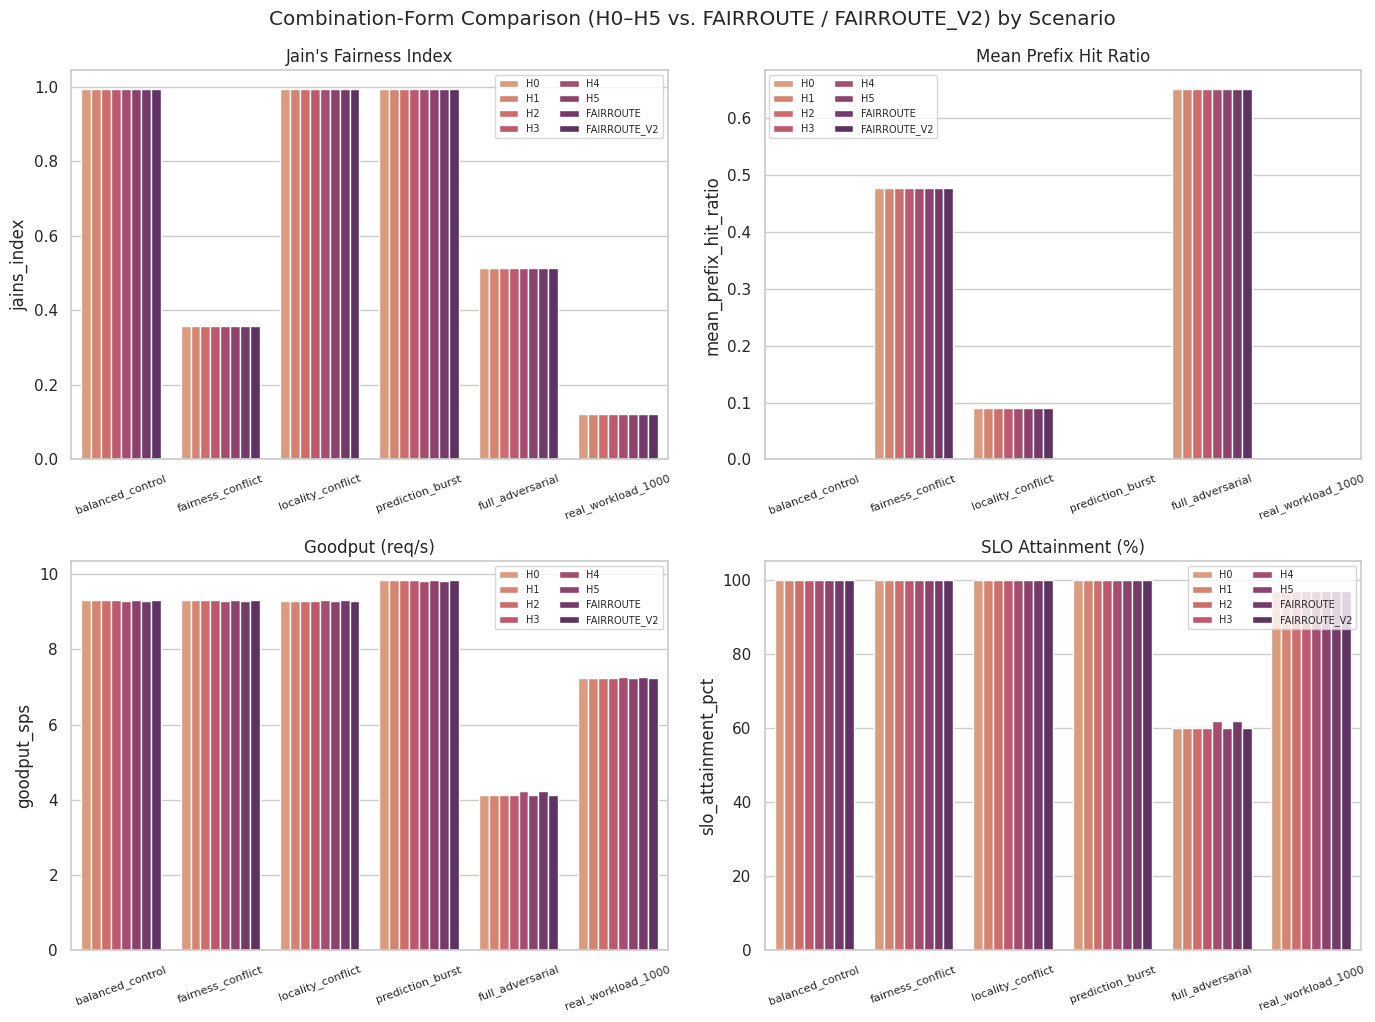

In [9]:

form_summary = summary[summary["policy_name"].isin(FORM_POLICIES)].copy()
form_summary["policy_name"] = pd.Categorical(form_summary["policy_name"], categories=FORM_POLICIES, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
form_metrics = [
    ("jains_index", "Jain's Fairness Index"),
    ("mean_prefix_hit_ratio", "Mean Prefix Hit Ratio"),
    ("goodput_sps", "Goodput (req/s)"),
    ("slo_attainment_pct", "SLO Attainment (%)"),
]
for axis, (metric, title) in zip(axes.flat, form_metrics):
    sns.barplot(data=form_summary, x="scenario", y=metric, hue="policy_name",
                hue_order=FORM_POLICIES, palette=sns.color_palette("flare", len(FORM_POLICIES)), ax=axis)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20, labelsize=8)
    axis.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.suptitle("Combination-Form Comparison (H0–H5 vs. FAIRROUTE / FAIRROUTE_V2) by Scenario", y=1.02)
plt.show()


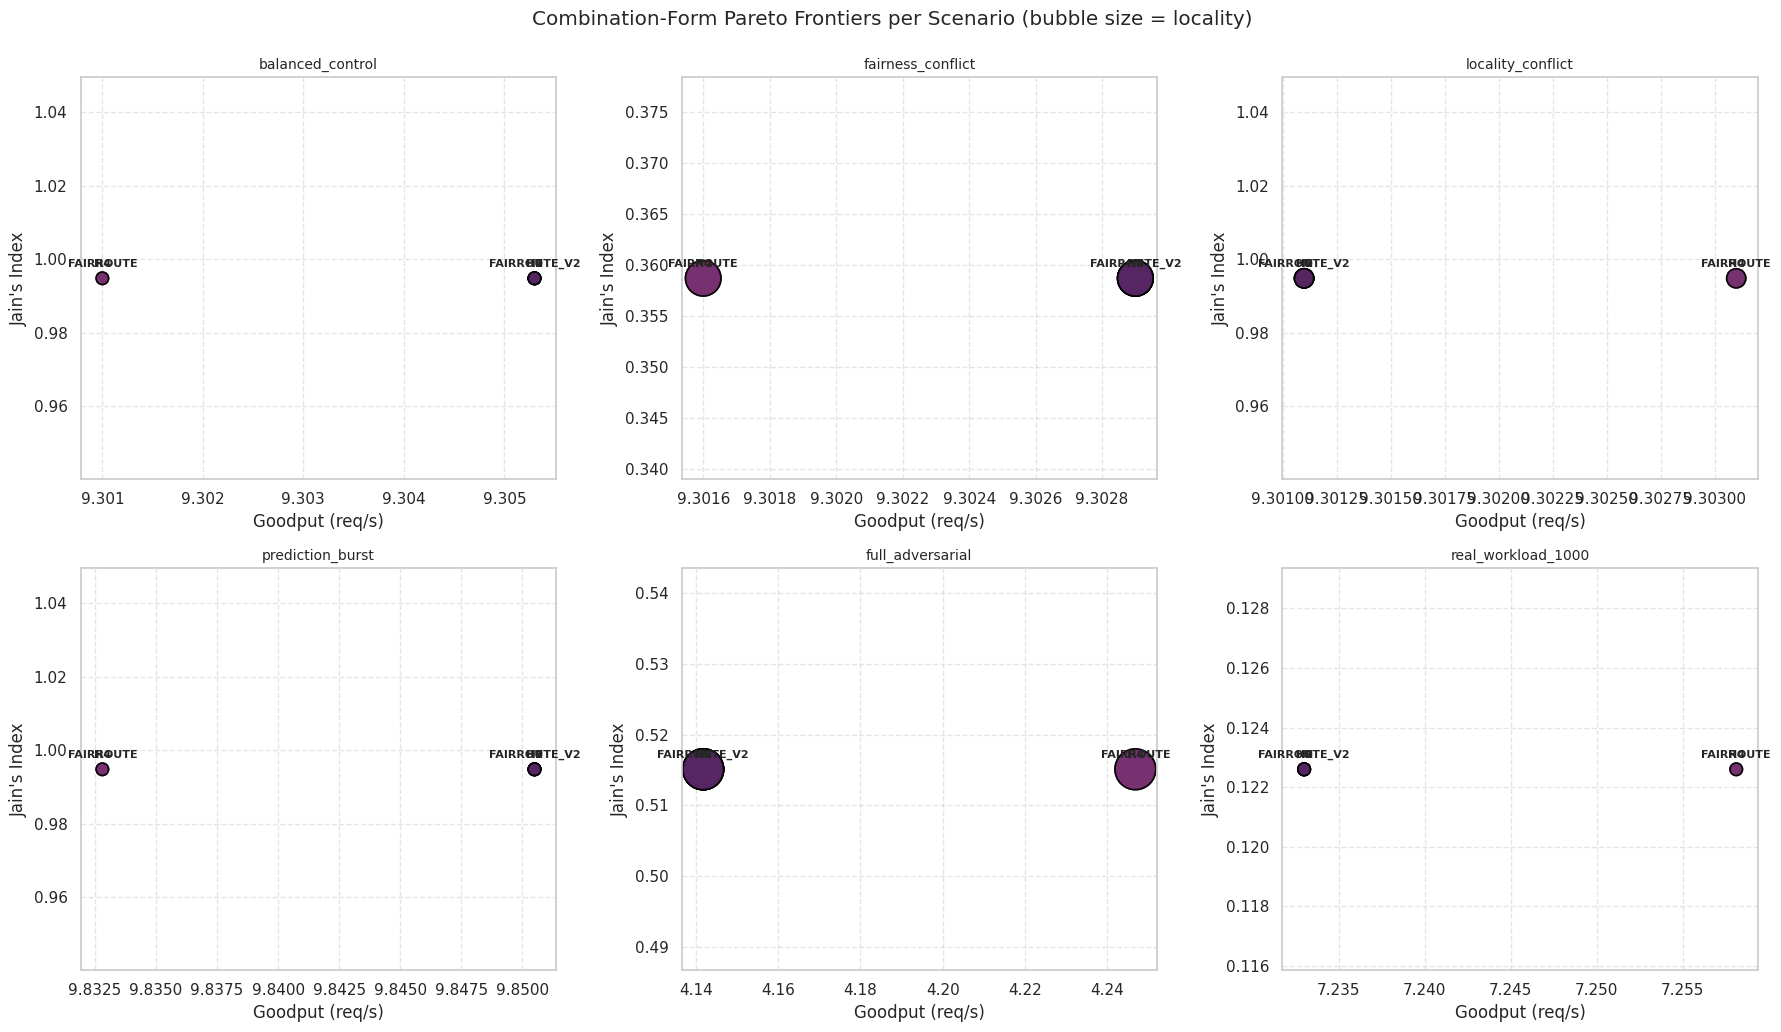

In [10]:

# Fairness x Goodput Pareto frontier, one panel per scenario, bubble size = locality
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, scen in zip(axes.flat, SCENARIO_ORDER):
    sub = form_summary[form_summary["scenario"] == scen]
    if sub.empty:
        axis.axis("off")
        continue
    sc = axis.scatter(sub["goodput_sps"], sub["jains_index"],
                       s=sub["mean_prefix_hit_ratio"] * 1200 + 80,
                       c=range(len(sub)), cmap="flare", edgecolors="black", linewidth=1.2, alpha=0.85)
    for _, row in sub.iterrows():
        axis.annotate(row["policy_name"], (row["goodput_sps"], row["jains_index"]),
                      textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, fontweight="bold")
    axis.set_title(scen, fontsize=10)
    axis.set_xlabel("Goodput (req/s)")
    axis.set_ylabel("Jain's Index")
    axis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.suptitle("Combination-Form Pareto Frontiers per Scenario (bubble size = locality)", y=1.03)
plt.show()


In [11]:

# Statistical significance: FAIRROUTE vs. each H-form and vs. the best prior-art baseline,
# paired across the 6 scenarios (Wilcoxon signed-rank; n=6 is small, treat as directional evidence).
def paired_test(metric, higher_is_better=True):
    fr = summary[summary["policy_name"] == "FAIRROUTE"].set_index("scenario")[metric]
    rows = []
    for other in [p for p in POLICY_ORDER if p != "FAIRROUTE"]:
        other_vals = summary[summary["policy_name"] == other].set_index("scenario")[metric]
        common = fr.index.intersection(other_vals.index)
        if len(common) < 3:
            continue
        a, b = fr.loc[common], other_vals.loc[common]
        diff = (a - b) if higher_is_better else (b - a)
        try:
            stat, p = stats.wilcoxon(a, b)
        except ValueError:
            stat, p = np.nan, np.nan
        rows.append({
            "vs_policy": other, "category": POLICY_CATEGORY.get(other, "Other"),
            "mean_advantage": diff.mean(), "wins": int((diff > 0).sum()), "n_scenarios": len(common),
            "wilcoxon_p": p,
        })
    return pd.DataFrame(rows).sort_values("mean_advantage", ascending=False)

print("=== FAIRROUTE vs. all other policies — Goodput (req/s) ===")
display(paired_test("goodput_sps", higher_is_better=True))

print("\n=== FAIRROUTE vs. all other policies — Jain's Fairness Index ===")
display(paired_test("jains_index", higher_is_better=True))


=== FAIRROUTE vs. all other policies — Goodput (req/s) ===


,vs_policy,category,mean_advantage,wins,n_scenarios,wilcoxon_p
18,NEXUSSCHED,Prior Art,1.766350,4,6,0.31250
11,LBGR,Prior Art,0.531800,3,6,0.56250
4,LOCALITY,Single-Signal,0.531800,3,6,0.56250
2,RAND,Naive,0.399450,5,6,0.21875
6,F_L,Pairwise,0.214750,4,6,0.43750
0,RR,Naive,0.179717,2,6,0.56250
27,H5,Combination-Form Hypothesis,0.018133,3,6,0.68750
25,H3,Combination-Form Hypothesis,0.018133,3,6,0.68750
24,H2,Combination-Form Hypothesis,0.018133,3,6,0.68750
23,H1,Combination-Form Hypothesis,0.018133,3,6,0.68750



=== FAIRROUTE vs. all other policies — Jain's Fairness Index ===


,vs_policy,category,mean_advantage,wins,n_scenarios,wilcoxon_p
0,RR,Naive,0.0,0,6,NaN
15,EQUINOX,Prior Art,0.0,0,6,NaN
27,H5,Combination-Form Hypothesis,0.0,0,6,NaN
26,H4,Combination-Form Hypothesis,0.0,0,6,NaN
25,H3,Combination-Form Hypothesis,0.0,0,6,NaN
24,H2,Combination-Form Hypothesis,0.0,0,6,NaN
23,H1,Combination-Form Hypothesis,0.0,0,6,NaN
22,H0,Combination-Form Hypothesis,0.0,0,6,NaN
21,ONLINE_LP,Prior Art,0.0,0,6,NaN
20,PILLM,Prior Art,0.0,0,6,NaN


## 6. Predictive validity: does the `prediction` signal track reality?

For policies that use a prediction component, a well-calibrated forecast of
near-future load should be **negatively** correlated with the queueing delay the
request actually experiences (routing away from soon-to-be-congested replicas).

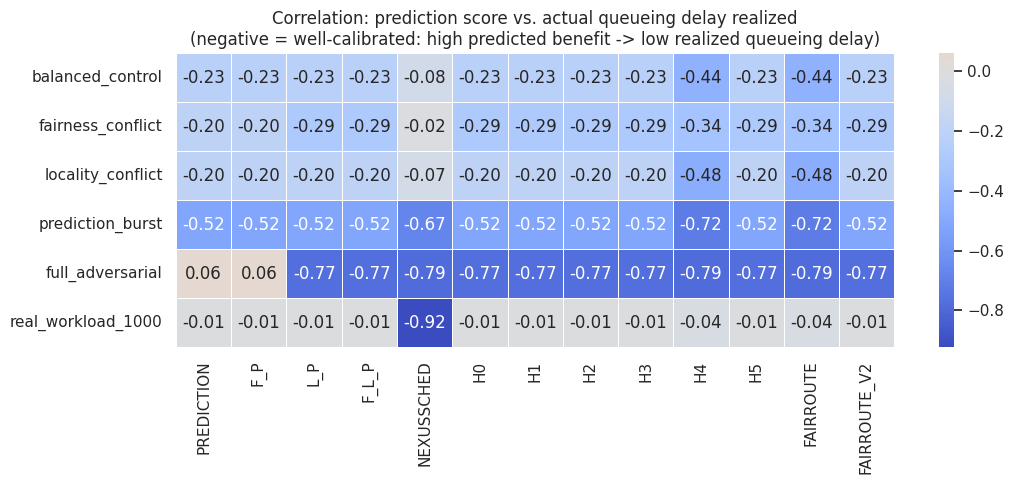

In [12]:

pred_policies = ["PREDICTION", "F_P", "L_P", "F_L_P", "NEXUSSCHED",
                  "H0", "H1", "H2", "H3", "H4", "H5", "FAIRROUTE", "FAIRROUTE_V2"]
corr_tbl = summary[summary["policy_name"].isin(pred_policies)][
    ["scenario", "policy_name", "prediction_vs_actual_queue_corr"]
].pivot(index="scenario", columns="policy_name", values="prediction_vs_actual_queue_corr")
corr_tbl = corr_tbl.reindex(columns=[p for p in pred_policies if p in corr_tbl.columns])

plt.figure(figsize=(11, 5))
sns.heatmap(corr_tbl, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation: prediction score vs. actual queueing delay realized\n"
          "(negative = well-calibrated: high predicted benefit -> low realized queueing delay)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 7. Overall leaderboard — rank aggregation across all 6 scenarios

=== Overall Leaderboard (lower avg_composite_rank = better, averaged over 6 metrics x 6 scenarios) ===


,policy_name,avg_composite_rank,category
1,FAIRROUTE_V2,6.861111,FairRoute (v2 / H5)
2,H5,6.861111,Combination-Form Hypothesis
3,H3,6.861111,Combination-Form Hypothesis
4,H2,6.861111,Combination-Form Hypothesis
5,H1,6.861111,Combination-Form Hypothesis
6,H0,6.861111,Combination-Form Hypothesis
7,L_P,6.861111,Pairwise
8,F_L_P,6.861111,Naive Linear Triple
9,PILLM,7.000000,Prior Art
10,QUARTZ,7.000000,Prior Art


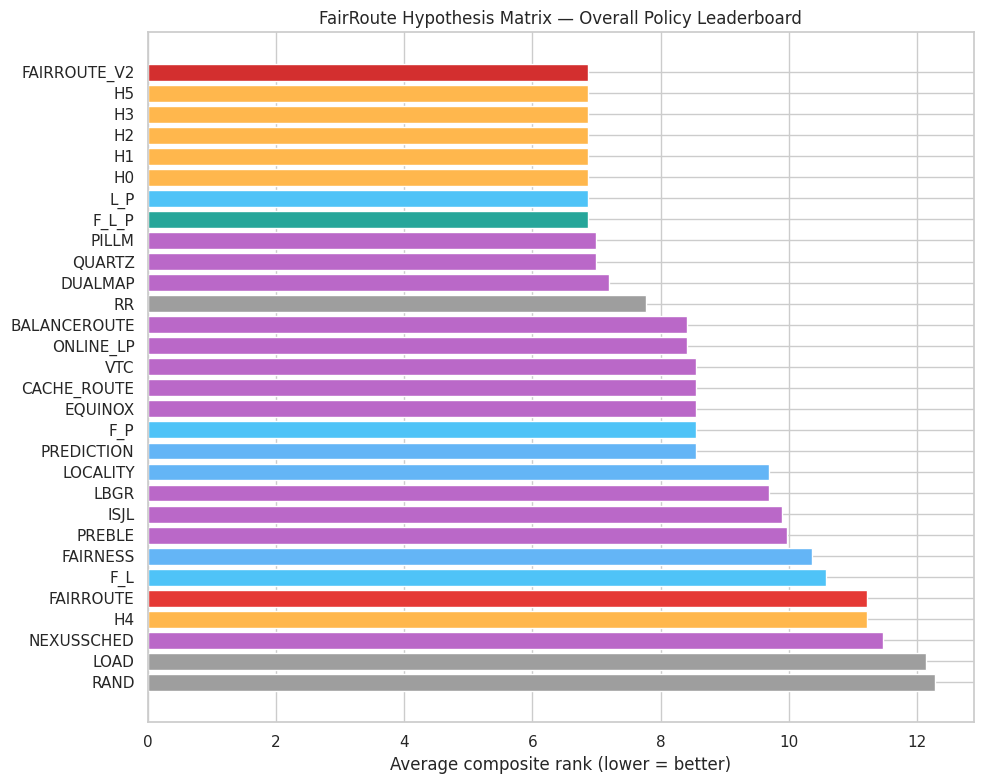


Saved leaderboard to fairroute_hypothesis_leaderboard.csv


In [13]:

rank_metrics = {
    "goodput_sps": False,          # higher is better -> ascending=False
    "jains_index": False,
    "slo_attainment_pct": False,
    "mean_prefix_hit_ratio": False,
    "ttft_p99_ms": True,           # lower is better -> ascending=True
    "replica_load_cv": True,
}

rank_frames = []
for metric, ascending in rank_metrics.items():
    r = summary.copy()
    r[f"rank_{metric}"] = r.groupby("scenario", observed=True)[metric].rank(ascending=ascending, method="min")
    rank_frames.append(r[["scenario", "policy_name", f"rank_{metric}"]])

ranked = rank_frames[0]
for f in rank_frames[1:]:
    ranked = ranked.merge(f, on=["scenario", "policy_name"])

rank_cols = [c for c in ranked.columns if c.startswith("rank_")]
ranked["composite_rank"] = ranked[rank_cols].mean(axis=1)

leaderboard = (
    ranked.groupby("policy_name", observed=True)["composite_rank"]
    .mean().reset_index().rename(columns={"composite_rank": "avg_composite_rank"})
    .sort_values("avg_composite_rank")
)
leaderboard["category"] = leaderboard["policy_name"].map(POLICY_CATEGORY)
leaderboard = leaderboard.reset_index(drop=True)
leaderboard.index += 1

print("=== Overall Leaderboard (lower avg_composite_rank = better, averaged over 6 metrics x 6 scenarios) ===")
display(leaderboard)

plt.figure(figsize=(10, 8))
bar_colors = [CATEGORY_COLOR.get(c, "#888") for c in leaderboard["category"]]
plt.barh(leaderboard["policy_name"].astype(str), leaderboard["avg_composite_rank"], color=bar_colors)
plt.gca().invert_yaxis()
plt.xlabel("Average composite rank (lower = better)")
plt.title("FairRoute Hypothesis Matrix — Overall Policy Leaderboard")
plt.tight_layout()
plt.show()

leaderboard.to_csv("/home/sriram/sem7/p1/mnt/user-data/outputs/fairroute_hypothesis_leaderboard.csv")
print("\nSaved leaderboard to fairroute_hypothesis_leaderboard.csv")


## 8. Single-scenario deep dive

Set `SELECTED_SCENARIO` below to drill into one scenario with the full
causal-chain view (routing → fairness/locality/prediction → scheduling →
latency → SLO/goodput). Defaults to the real trace replay.

In [14]:

SELECTED_SCENARIO = "real_workload_1000"  # change to any of SCENARIO_ORDER
assert SELECTED_SCENARIO in SCENARIO_ORDER

df = requests_df[requests_df["scenario"] == SELECTED_SCENARIO].copy()
df["policy_name"] = df["policy_name"].cat.remove_unused_categories()
active_policies = ordered(df["policy_name"].unique().tolist(), POLICY_ORDER)
print(f"Deep-diving into scenario = {SELECTED_SCENARIO!r} "
      f"({len(df):,} requests across {len(active_policies)} policies)")


Deep-diving into scenario = 'real_workload_1000' (30,000 requests across 30 policies)


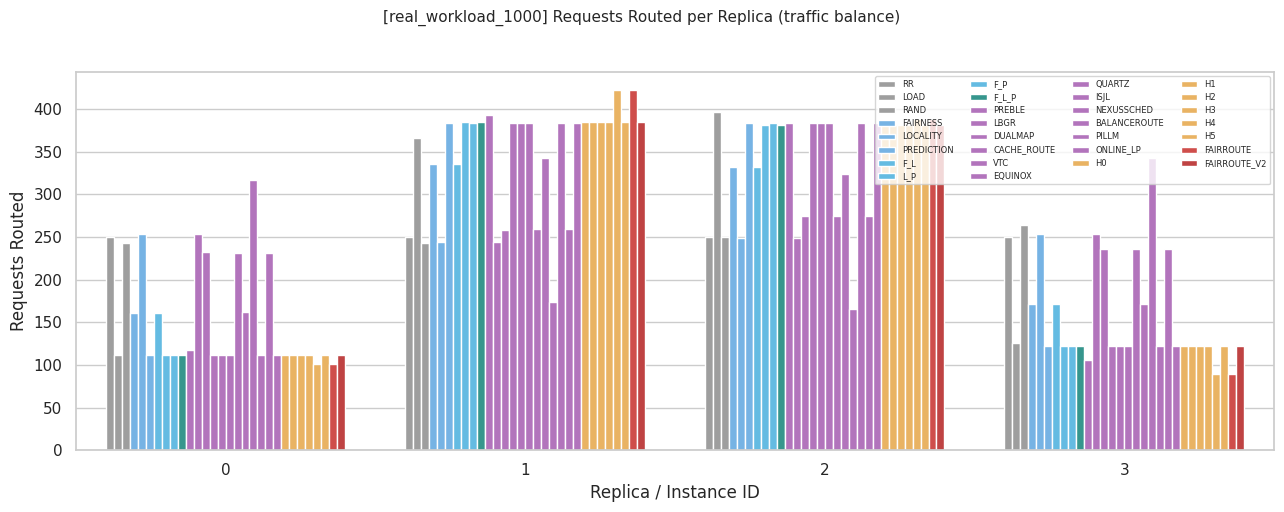

In [15]:

plt.figure(figsize=(13, 5))
req_counts = df.groupby(["policy_name", "instance id"], observed=True).size().reset_index(name="count")
sns.barplot(data=req_counts, x="instance id", y="count", hue="policy_name",
            hue_order=active_policies, palette=PALETTE)
plt.ylabel("Requests Routed")
plt.xlabel("Replica / Instance ID")
plt.legend(fontsize=6, ncol=4, loc="upper right")
savefig_note(f"[{SELECTED_SCENARIO}] Requests Routed per Replica (traffic balance)")
plt.show()


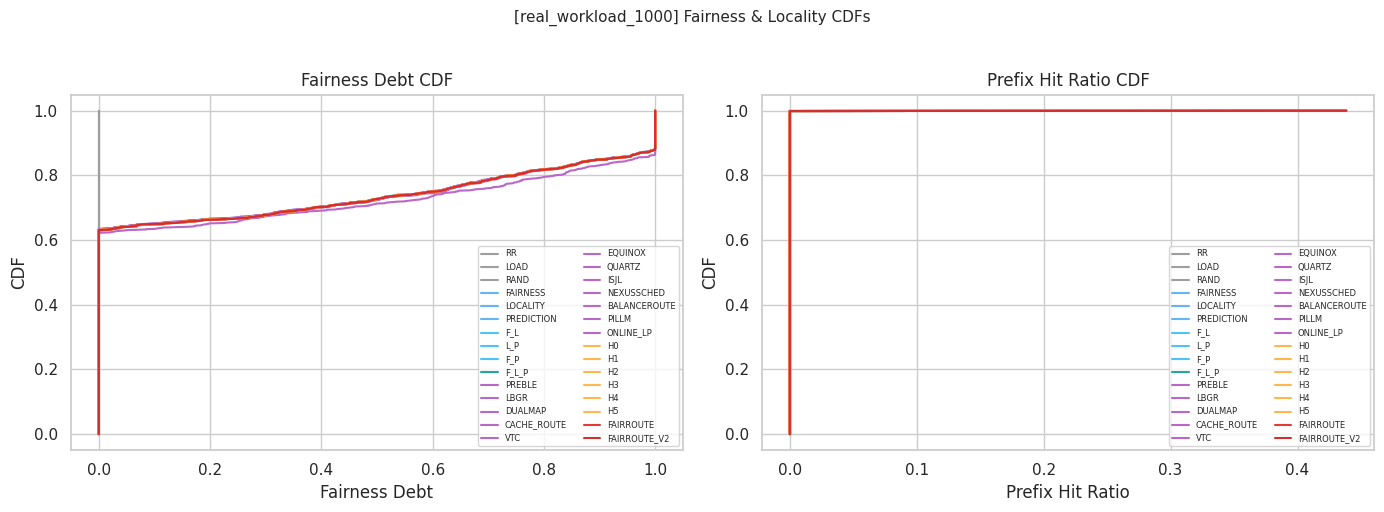

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pol in active_policies:
    sub = df[df["policy_name"] == pol]["fairness debt"].sort_values()
    axes[0].plot(sub.values, np.linspace(0, 1, len(sub)), label=pol, color=PALETTE.get(pol, "#333"), linewidth=1.5)
axes[0].set_xlabel("Fairness Debt"); axes[0].set_ylabel("CDF")
axes[0].set_title("Fairness Debt CDF")
axes[0].legend(fontsize=6, ncol=2)

for pol in active_policies:
    sub = df[df["policy_name"] == pol]["prefix_hit_ratio"].sort_values()
    axes[1].plot(sub.values, np.linspace(0, 1, len(sub)), label=pol, color=PALETTE.get(pol, "#333"), linewidth=1.5)
axes[1].set_xlabel("Prefix Hit Ratio"); axes[1].set_ylabel("CDF")
axes[1].set_title("Prefix Hit Ratio CDF")
axes[1].legend(fontsize=6, ncol=2)
savefig_note(f"[{SELECTED_SCENARIO}] Fairness & Locality CDFs")
plt.show()


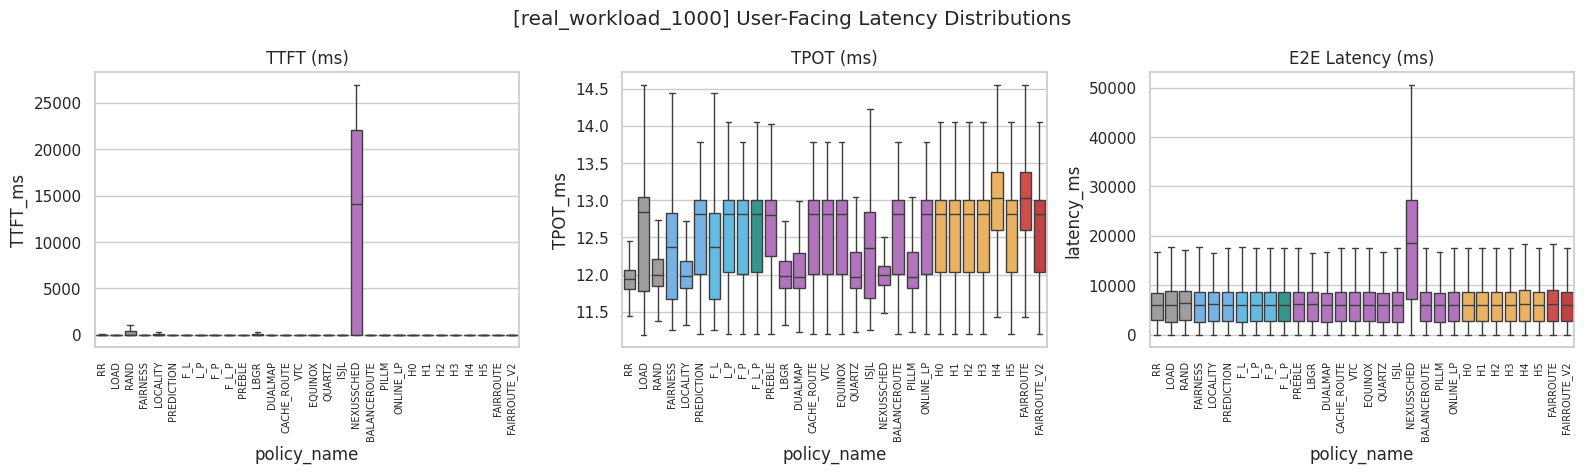

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="policy_name", y="TTFT_ms", order=active_policies, palette=PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title("TTFT (ms)"); axes[0].tick_params(axis="x", rotation=90, labelsize=7)
sns.boxplot(data=df, x="policy_name", y="TPOT_ms", order=active_policies, palette=PALETTE, ax=axes[1], showfliers=False)
axes[1].set_title("TPOT (ms)"); axes[1].tick_params(axis="x", rotation=90, labelsize=7)
sns.boxplot(data=df, x="policy_name", y="latency_ms", order=active_policies, palette=PALETTE, ax=axes[2], showfliers=False)
axes[2].set_title("E2E Latency (ms)"); axes[2].tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.suptitle(f"[{SELECTED_SCENARIO}] User-Facing Latency Distributions", y=1.05)
plt.show()


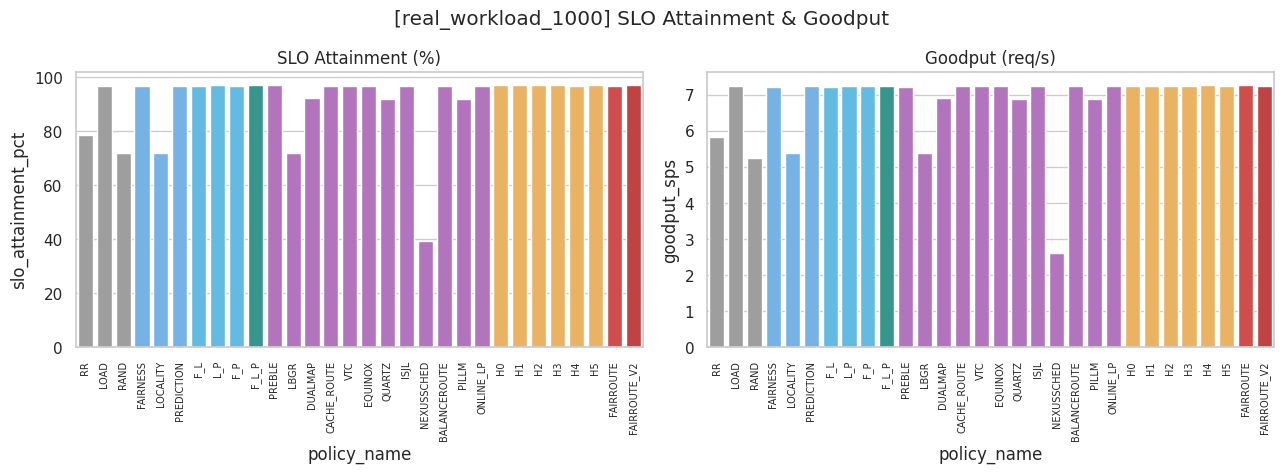

,n_requests,jains_index,mean_prefix_hit_ratio,ttft_p99_ms,e2e_p99_ms,slo_attainment_pct,goodput_sps,total_preemptions,replica_load_cv,energy_proxy_kj
policy_name,,,,,,,,,,
RR,1000,0.1226,0.0004,2423.4825,17119.4766,78.6,5.8284,0,0.0000,33.7140
LOAD,1000,0.1226,0.0000,61.1590,17650.0216,96.9,7.2298,0,0.5261,33.5071
RAND,1000,0.1226,0.0004,3484.8294,18033.7230,71.8,5.2485,0,0.0343,34.2003
FAIRNESS,1000,0.1226,0.0004,79.7579,17569.4826,96.7,7.2148,0,0.3344,33.5074
LOCALITY,1000,0.1226,0.0004,2484.2501,17551.8916,72.1,5.3922,0,0.0157,33.4277
PREDICTION,1000,0.1226,0.0000,64.2599,17639.4471,96.9,7.2489,0,0.5322,33.4187
F_L,1000,0.1226,0.0004,79.7579,17569.4826,96.7,7.2148,0,0.3344,33.5074
L_P,1000,0.1226,0.0004,61.8963,17609.8776,97.0,7.2330,0,0.5322,33.5270
F_P,1000,0.1226,0.0000,64.2599,17639.4471,96.9,7.2489,0,0.5322,33.4187


In [18]:

scen_summary = summary[summary["scenario"] == SELECTED_SCENARIO].set_index("policy_name").loc[active_policies]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=scen_summary.index.astype(str), y=scen_summary["slo_attainment_pct"], palette=PALETTE, ax=axes[0])
axes[0].set_title("SLO Attainment (%)"); axes[0].tick_params(axis="x", rotation=90, labelsize=7)
sns.barplot(x=scen_summary.index.astype(str), y=scen_summary["goodput_sps"], palette=PALETTE, ax=axes[1])
axes[1].set_title("Goodput (req/s)"); axes[1].tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.suptitle(f"[{SELECTED_SCENARIO}] SLO Attainment & Goodput", y=1.05)
plt.show()

display(scen_summary[["n_requests", "jains_index", "mean_prefix_hit_ratio", "ttft_p99_ms",
                        "e2e_p99_ms", "slo_attainment_pct", "goodput_sps", "total_preemptions",
                        "replica_load_cv", "energy_proxy_kj"]])


## 9. Export results

In [19]:

requests_df.drop(columns=["ITL"], errors="ignore").to_csv(
    "/home/sriram/sem7/p1/mnt/user-data/outputs/fairroute_hypothesis_requests_full.csv.gz",
    index=False, compression="gzip"
)
print("Exported:")
print(" - fairroute_hypothesis_summary.csv          (per scenario x policy metrics)")
print(" - fairroute_hypothesis_leaderboard.csv       (overall ranked policy leaderboard)")
print(" - fairroute_hypothesis_requests_full.csv.gz  (full concatenated per-request matrix, compressed)")
print(f"\nTop 5 policies overall: {', '.join(leaderboard['policy_name'].astype(str).head(5))}")


Exported:
 - fairroute_hypothesis_summary.csv          (per scenario x policy metrics)
 - fairroute_hypothesis_leaderboard.csv       (overall ranked policy leaderboard)
 - fairroute_hypothesis_requests_full.csv.gz  (full concatenated per-request matrix, compressed)

Top 5 policies overall: FAIRROUTE_V2, H5, H3, H2, H1
